In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import utils
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
# Загрузка базы MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Форма обучающей выборки:", x_train.shape)
print("Форма тестовой выборки:", x_test.shape)

# Подготовка данных
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

print("Форма x_train:", x_train.shape)
print("Форма y_train:", y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Форма обучающей выборки: (60000, 28, 28)
Форма тестовой выборки: (10000, 28, 28)
Форма x_train: (60000, 784)
Форма y_train: (60000, 10)


In [3]:
# Созание модели
model = Sequential()
model.add(Dense(800, input_dim=784, activation="relu"))
model.add(Dense(400, activation="relu"))
model.add(Dense(10, activation="softmax"))

model.compile(loss="categorical_crossentropy", optimizer=Adam(), metrics=["accuracy"])

model.summary()

# Обучение модели
history = model.fit(x_train, y_train, batch_size=128, epochs=20, validation_split=0.2, verbose=1)

# Проверка точности тестовой выборки
scores = model.evaluate(x_test, y_test, verbose=0)
print("Точность на тестовой выборке:", round(scores[1] * 100, 2), "%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 800)            │       628,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 400)            │       320,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         4,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 952,410 (3.63 MB)

 Trainable params: 952,410 (3.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9314 - loss: 0.2323 - val_accuracy: 0.9626 - val_loss: 0.1229
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9737 - loss: 0.0842 - val_accuracy: 0.9738 - val_loss: 0.0885
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9838 - loss: 0.0493 - val_accuracy: 0.9746 - val_loss: 0.0897
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9889 - loss: 0.0335 - val_accuracy: 0.9755 - val_loss: 0.0858
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9919 - loss: 0.0258 - val_accuracy: 0.9753 - val_loss: 0.0900
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9931 - loss: 0.0216 - val_accuracy: 0.9759 - val_loss: 0.0887
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9938 - loss: 0.0186 - val_accuracy: 0.9768 - val_loss: 0.0945
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9947 - loss: 0.0154 - val

Saving 6.png to 6 (2).png
Загружен файл: 6 (2).png


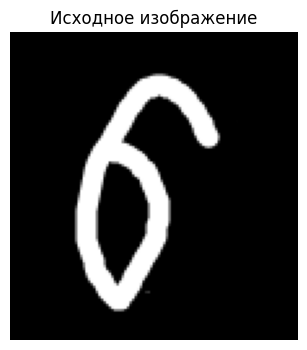

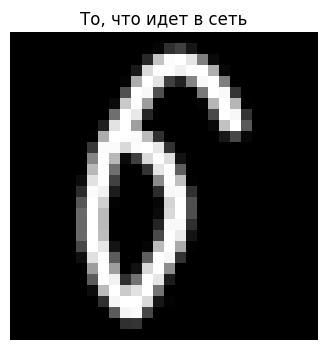

Форма для подачи в сеть: (1, 784)


In [34]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Загрузка картинки
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Загружен файл:", filename)

# Открываем в сером формате
img = Image.open(filename).convert("L")
img_array = np.array(img)

plt.figure(figsize=(4, 4))
plt.imshow(img_array, cmap='gray')
plt.title("Исходное изображение")
plt.axis("off")
plt.show()

# Определяем фон по краям
border = np.concatenate([
    img_array[0, :],
    img_array[-1, :],
    img_array[:, 0],
    img_array[:, -1]
])

# Если фон светлый — инвертируем
if border.mean() > 127:
    img_array = 255 - img_array

# Убираем слабый шум
img_array[img_array < 20] = 0

# Находим область цифры
coords = np.argwhere(img_array > 20)
if len(coords) == 0:
    raise ValueError("Цифра не найдена")

y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)

# Обрезаем только цифру
img_array = img_array[y_min:y_max+1, x_min:x_max+1]

# Вписываем в квадрат
h, w = img_array.shape
size = max(h, w) + 12
square = np.zeros((size, size), dtype=np.uint8)

y_offset = (size - h) // 2
x_offset = (size - w) // 2
square[y_offset:y_offset+h, x_offset:x_offset+w] = img_array

# Масштабируем до 28x28
img_final = Image.fromarray(square).resize((28, 28))
img_final = np.array(img_final).astype("float32") / 255.0

# Показываем, что реально идет в сеть
plt.figure(figsize=(4, 4))
plt.imshow(img_final, cmap="gray", interpolation="nearest")
plt.title("То, что идет в сеть")
plt.axis("off")
plt.show()

# Готовим вектор для сети
img_vector = img_final.reshape(1, 784)
print("Форма для подачи в сеть:", img_vector.shape)

In [35]:
# Распознавание цифры
prediction = model.predict(img_vector)
predicted_digit = np.argmax(prediction)

print("Распознанная цифра:", predicted_digit)
print("Вероятности по классам:")

for i in range(10):
    print(f"{i}: {prediction[0][i]:.6f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Распознанная цифра: 6
Вероятности по классам:
0: 0.000282
1: 0.000332
2: 0.000000
3: 0.000000
4: 0.000005
5: 0.010652
6: 0.987752
7: 0.000026
8: 0.000950
9: 0.000000
